In [1]:
!pip install google-cloud-bigquery pandas matplotlib scipy --quiet

In [2]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
client = bigquery.Client(project='ecommerce-retention-case-study')

In [3]:
aov_query = """
WITH session_level AS (
  SELECT
    CONCAT(user_pseudo_id, '-',
      CAST((SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS STRING)
    ) AS session_id,
    MAX((SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_number')) AS session_number,
    SUM(IF(event_name = 'purchase', ecommerce.purchase_revenue_in_usd, NULL)) AS order_value
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
  GROUP BY session_id
)
SELECT
  IF(session_number = 1, 'new_user', 'returning_user') AS user_type,
  order_value
FROM session_level
WHERE order_value IS NOT NULL AND order_value > 0
"""

aov_df = client.query(aov_query).to_dataframe()
print(aov_df.shape)
aov_df.head()

(4446, 2)


,user_type,order_value
0,new_user,50.0
1,returning_user,11.0
2,new_user,48.0
3,returning_user,16.0
4,new_user,33.0


                 count       mean         std  min   25%   50%   75%     max
user_type                                                                   
new_user        1648.0  73.827670   81.698154  1.0  27.0  50.0  90.0   904.0
returning_user  2798.0  85.953181  107.697747  3.0  32.0  55.0  97.0  1530.0


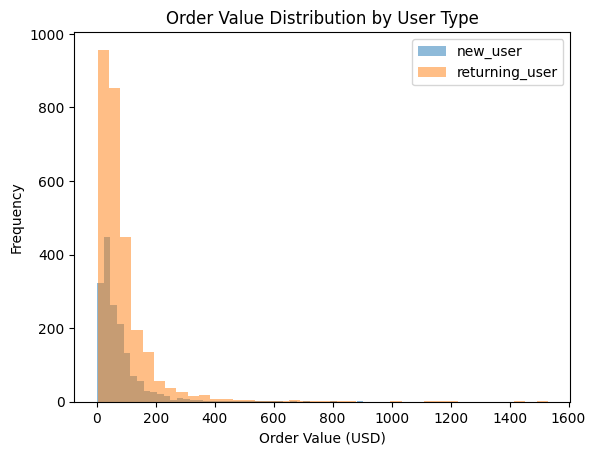

In [4]:
import matplotlib.pyplot as plt

print(aov_df.groupby('user_type')['order_value'].describe())

fig, ax = plt.subplots()
for user_type in ['new_user', 'returning_user']:
    subset = aov_df[aov_df['user_type'] == user_type]['order_value']
    ax.hist(subset, bins=40, alpha=0.5, label=user_type)
ax.set_xlabel('Order Value (USD)')
ax.set_ylabel('Frequency')
ax.legend()
ax.set_title('Order Value Distribution by User Type')
plt.savefig('aov_distribution.png')
plt.show()

In [5]:
from scipy.stats import chi2_contingency
import numpy as np
from scipy.stats import norm

def chi_square_test(purchases_a, sessions_a, purchases_b, sessions_b):
    table = [[purchases_a, sessions_a - purchases_a],
             [purchases_b, sessions_b - purchases_b]]
    chi2, p_value, dof, expected = chi2_contingency(table)
    return chi2, p_value

# New vs returning
chi2_val, p_val = chi_square_test(1780, 261238, 3068, 98891)
print(f"New vs Returning users — chi2: {chi2_val:.2f}, p-value: {p_val:.6f}")

# Device: mobile vs desktop
chi2_val, p_val = chi_square_test(1995, 143185, 2749, 208942)
print(f"Mobile vs Desktop — chi2: {chi2_val:.2f}, p-value: {p_val:.6f}")

# Confidence intervals
def conversion_ci(purchases, sessions, confidence=0.95):
    p_hat = purchases / sessions
    z = norm.ppf(1 - (1 - confidence) / 2)
    se = np.sqrt(p_hat * (1 - p_hat) / sessions)
    margin = z * se
    return p_hat*100, (p_hat - margin)*100, (p_hat + margin)*100

for label, purchases, sessions in [('New users', 1780, 261238), ('Returning users', 3068, 98891)]:
    p_hat, lower, upper = conversion_ci(purchases, sessions)
    print(f"{label}: {p_hat:.2f}% (95% CI: {lower:.2f}%–{upper:.2f}%)")

New vs Returning users — chi2: 3164.23, p-value: 0.000000
Mobile vs Desktop — chi2: 3.79, p-value: 0.051442
New users: 0.68% (95% CI: 0.65%–0.71%)
Returning users: 3.10% (95% CI: 2.99%–3.21%)


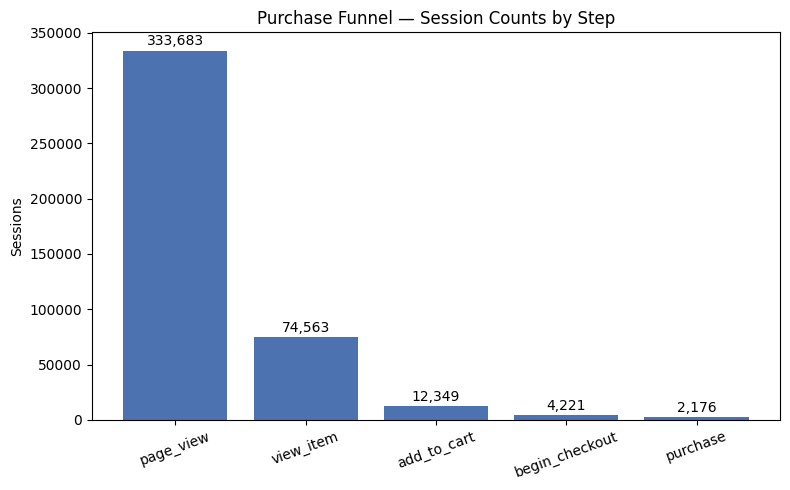

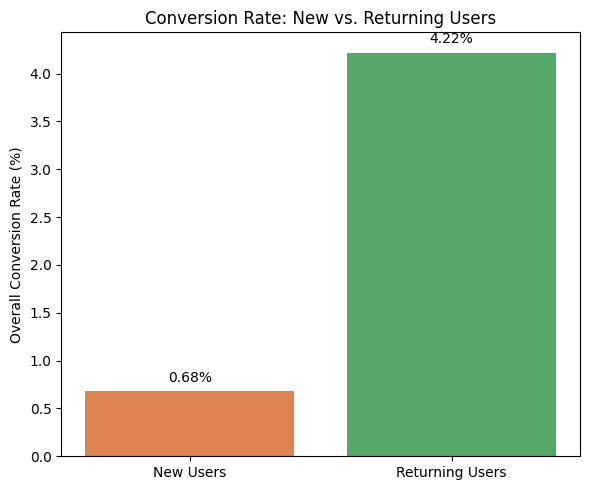

In [6]:
# Funnel chart
steps = ['page_view', 'view_item', 'add_to_cart', 'begin_checkout', 'purchase']
values = [333683, 74563, 12349, 4221, 2176]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(steps, values, color='#4C72B0')
ax.set_ylabel('Sessions')
ax.set_title('Purchase Funnel — Session Counts by Step')
for i, v in enumerate(values):
    ax.text(i, v + 5000, f'{v:,}', ha='center')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('funnel_chart.png')
plt.show()

# New vs returning chart
fig, ax = plt.subplots(figsize=(6, 5))
categories = ['New Users', 'Returning Users']
conversion_rates = [0.68, 4.22]
ax.bar(categories, conversion_rates, color=['#DD8452', '#55A868'])
ax.set_ylabel('Overall Conversion Rate (%)')
ax.set_title('Conversion Rate: New vs. Returning Users')
for i, v in enumerate(conversion_rates):
    ax.text(i, v + 0.1, f'{v}%', ha='center')
plt.tight_layout()
plt.savefig('new_vs_returning_chart.png')
plt.show()

In [9]:
from scipy.stats import mannwhitneyu

new_user_aov = aov_df[aov_df['user_type'] == 'new_user']['order_value']
returning_user_aov = aov_df[aov_df['user_type'] == 'returning_user']['order_value']

stat, p_value = mannwhitneyu(new_user_aov, returning_user_aov, alternative='two-sided')
print(f"Mann-Whitney U — statistic: {stat:.2f}, p-value: {p_value:.6f}")
print(f"New user median AOV: ${new_user_aov.median():.2f}")
print(f"Returning user median AOV: ${returning_user_aov.median():.2f}")

Mann-Whitney U — statistic: 2112141.00, p-value: 0.000003
New user median AOV: $50.00
Returning user median AOV: $55.00


In [10]:
countries_data = {
    'United States': (158155, 2117),
    'India': (33769, 449),
    'Canada': (26824, 390),
    'United Kingdom': (11327, 151),
    'France': (7162, 102),
    'Spain': (6667, 99),
    'Germany': (6393, 81),
    'China': (6258, 80),
    'Taiwan': (6057, 80),
    'Italy': (4998, 55),
    'Singapore': (4741, 55),
    'Japan': (4732, 76),
    'South Korea': (4523, 52),
    'Netherlands': (4073, 61),
    'Turkey': (3646, 54),
    'Brazil': (3596, 55),
    'Australia': (3341, 46),
    'Indonesia': (3244, 26),
    'Poland': (3142, 50),
    'Mexico': (3031, 42),
}

table = [[purchases, sessions - purchases] for sessions, purchases in countries_data.values()]

chi2_val, p_val, dof, expected = chi2_contingency(table)
print(f"Geography (all 20 countries) — chi2: {chi2_val:.2f}, p-value: {p_val:.6f}, dof: {dof}")

Geography (all 20 countries) — chi2: 22.37, p-value: 0.266145, dof: 19
